### 1.1 Datenabruf und Filterung

Vorschlag: Daten ohne Limit einmal als csv runterladen. Ist dadurch reproduzierbarer

In [2]:
# Stationsmetadaten und gueltige Tageswerte zusammenfuehren

from wetterdienst import Settings
from wetterdienst.provider.dwd.observation import DwdObservationRequest
import pandas as pd
import os

# Cache aktiv lassen, damit wiederholte Abfragen schneller sind
settings = Settings(cache_disable=False)

start_date = "2026-03-17"
end_date = "2026-04-17"
date_label = start_date if start_date == end_date else f"{start_date} bis {end_date}"
csv_file = f"stations_data_{start_date}_to_{end_date}.csv"

# CSV laden oder neu herunterladen
if os.path.exists(csv_file):
    print(f"Lade Daten aus {csv_file}...")
    stations_with_data = pd.read_csv(csv_file)
    print(f"Anzahl Stationen mit gueltigem Wert: {len(stations_with_data)}")
else:
    print(f"Lade Daten vom DWD fuer {date_label}...")

    request = DwdObservationRequest(
        parameters=("daily", "climate_summary", "temperature_air_mean_2m"),
        start_date=start_date,
        end_date=end_date,
        settings=settings,
    )

    stations = request.all().df.to_pandas()
    values = request.all().values.all().df.to_pandas()
    values["value"] = pd.to_numeric(values["value"], errors="coerce")

    # Fuer Zeitraeume auf Stationsmittel aggregieren, damit jede Station nur einmal vorkommt.
    station_values = (
        values.loc[values["value"].notna(), ["station_id", "value"]]
        .groupby("station_id", as_index=False)["value"]
        .mean()
    )

    stations_with_data = stations.merge(
        station_values,
        on="station_id",
        how="inner",
    )

    # Speichere als CSV fuer zukuenftige Nutzung
    stations_with_data.to_csv(csv_file, index=False)
    print(f"Anzahl Stationen mit gueltigem Wert: {len(stations_with_data)}")
    print(f"Daten gespeichert in {csv_file}")

stations_with_data.info()
stations_with_data.head()

Lade Daten aus stations_data_2026-03-17_to_2026-04-17.csv...
Anzahl Stationen mit gueltigem Wert: 491
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   resolution  491 non-null    object 
 1   dataset     491 non-null    object 
 2   station_id  491 non-null    int64  
 3   start_date  491 non-null    object 
 4   end_date    491 non-null    object 
 5   latitude    491 non-null    float64
 6   longitude   491 non-null    float64
 7   height      491 non-null    float64
 8   name        491 non-null    object 
 9   state       491 non-null    object 
 10  value       491 non-null    float64
dtypes: float64(4), int64(1), object(6)
memory usage: 42.3+ KB


,resolution,dataset,station_id,start_date,end_date,latitude,longitude,height,name,state,value
0,daily,climate_summary,44,1969-01-01 00:00:00+00:00,2026-04-18 00:00:00+00:00,52.9336,8.2370,44.0,Großenkneten,Niedersachsen,8.100000
1,daily,climate_summary,73,1959-03-01 00:00:00+00:00,2026-04-18 00:00:00+00:00,48.6183,13.0620,374.0,Aldersbach-Kramersepp,Bayern,7.837500
2,daily,climate_summary,78,1961-01-01 00:00:00+00:00,2026-04-18 00:00:00+00:00,52.4853,7.9125,64.0,Alfhausen,Niedersachsen,8.196875
3,daily,climate_summary,91,1978-11-01 00:00:00+00:00,2026-04-18 00:00:00+00:00,50.7446,9.3450,304.0,Alsfeld-Eifa,Hessen,7.115625
4,daily,climate_summary,96,2019-04-09 00:00:00+00:00,2026-04-18 00:00:00+00:00,52.9437,12.8518,50.0,Neuruppin-Alt Ruppin,Brandenburg,6.850000


### 1.2 Deutschland laden & Daten projezieren

In [4]:
# Deutschland laden (inkl. Inseln) und Stationen projizieren

import geopandas as gpd
import numpy as np
from pyproj import Transformer

# GeoPandas lädt alle Polygone (Festland + Inseln) und projiziert nach EPSG:3035
germany = gpd.read_file("de.json").to_crs("EPSG:3035")
germany_geom = germany.geometry.unary_union  # MultiPolygon mit Festland + allen Inseln

# Stationen projizieren
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)

sx, sy = transformer.transform(
    stations_with_data["longitude"].to_numpy(),
    stations_with_data["latitude"].to_numpy(),
)

stations_with_data = stations_with_data.copy()
stations_with_data["x"] = sx
stations_with_data["y"] = sy
stations_with_data.head()

C:\Users\Hagen\AppData\Local\Temp\ipykernel_22824\4041677027.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  germany_geom = germany.geometry.unary_union  # MultiPolygon mit Festland + allen Inseln


,resolution,dataset,station_id,start_date,end_date,latitude,longitude,height,name,state,value,x,y
0,daily,climate_summary,44,1969-01-01 00:00:00+00:00,2026-04-18 00:00:00+00:00,52.9336,8.2370,44.0,Großenkneten,Niedersachsen,8.100000,4.202463e+06,3.315324e+06
1,daily,climate_summary,73,1959-03-01 00:00:00+00:00,2026-04-18 00:00:00+00:00,48.6183,13.0620,374.0,Aldersbach-Kramersepp,Bayern,7.837500,4.546768e+06,2.838567e+06
2,daily,climate_summary,78,1961-01-01 00:00:00+00:00,2026-04-18 00:00:00+00:00,52.4853,7.9125,64.0,Alfhausen,Niedersachsen,8.196875,4.179210e+06,3.266034e+06
3,daily,climate_summary,91,1978-11-01 00:00:00+00:00,2026-04-18 00:00:00+00:00,50.7446,9.3450,304.0,Alsfeld-Eifa,Hessen,7.115625,4.274768e+06,3.070538e+06
4,daily,climate_summary,96,2019-04-09 00:00:00+00:00,2026-04-18 00:00:00+00:00,52.9437,12.8518,50.0,Neuruppin-Alt Ruppin,Brandenburg,6.850000,4.512664e+06,3.318771e+06


In [5]:
# Zielraster und Maskierung vorbereiten (alle Polygone inkl. Inseln)

from matplotlib.path import Path

min_x, min_y, max_x, max_y = germany_geom.bounds

grid_x, grid_y = np.meshgrid(
    np.linspace(min_x, max_x, 140),
    np.linspace(min_y, max_y, 170),
)

targets = np.column_stack([grid_x.ravel(), grid_y.ravel()])

# Maske über alle Teilpolygone (Festland + Inseln)
inside_mask = np.zeros(len(targets), dtype=bool)
for poly in germany_geom.geoms:
    inside_mask |= Path(np.array(poly.exterior.coords)).contains_points(targets)

inside_mask = inside_mask.reshape(grid_x.shape)


In [6]:
# PyKrige auf projizierten Stationspunkten und Zielachsen ausführen

from pykrige.ok import OrdinaryKriging

ok = OrdinaryKriging(
    x=stations_with_data["x"].to_numpy(),
    y=stations_with_data["y"].to_numpy(),
    z=stations_with_data["value"].to_numpy(),
    variogram_model="spherical",
    coordinates_type="euclidean",
)

z_pred, z_var = ok.execute(
    "grid",
    np.linspace(min_x, max_x, 140),
    np.linspace(min_y, max_y, 170),
)

z_pred = np.where(inside_mask, np.asarray(z_pred, dtype=float), np.nan)
z_var = np.where(inside_mask, np.asarray(z_var, dtype=float), np.nan)


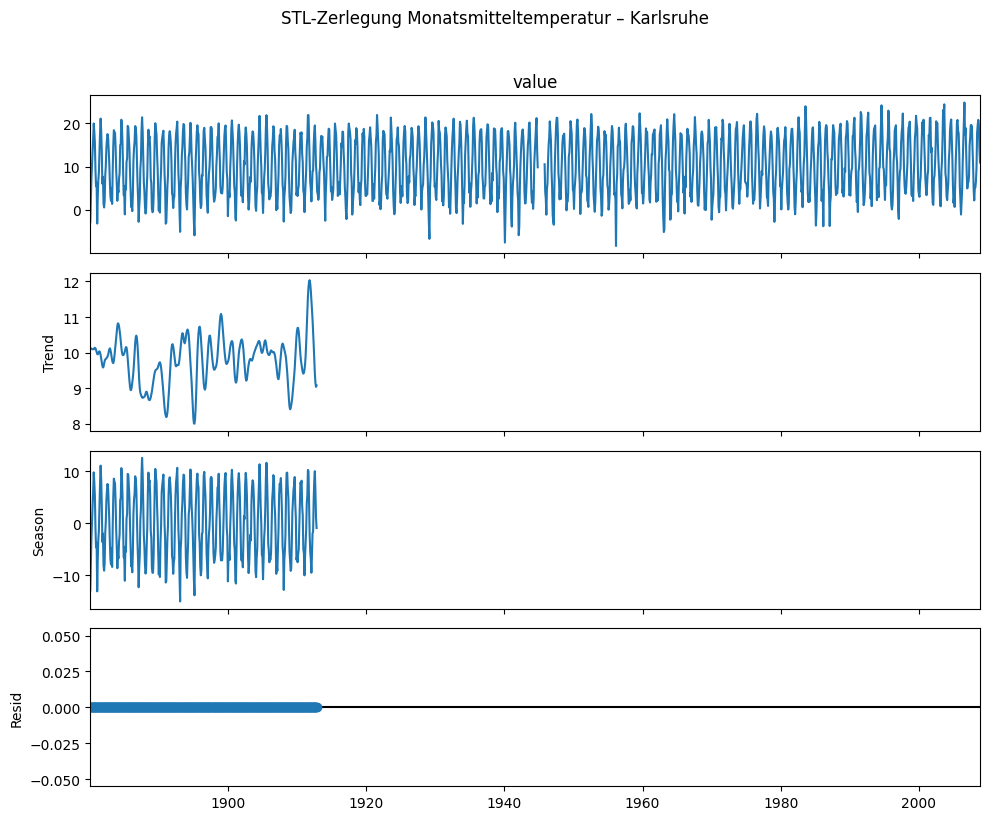

In [10]:
# Historische Reihe bis Ende 2025 auf Monatsmittel bringen und visualisieren

from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

station_name = "Karlsruhe"

station = DwdObservationRequest(
    parameters=("daily", "climate_summary", "temperature_air_mean_2m"),
    start_date="1880-01-01",
    end_date="2025-12-31",
    settings=settings,
).filter_by_name(name=station_name)

values = station.values.all().df.to_pandas()
values["date"] = pd.to_datetime(values["date"], utc=True)
values["value"] = pd.to_numeric(values["value"], errors="coerce")

monthly = (
    values.dropna(subset=["value"])
    .set_index("date")["value"]
    .resample("ME")
    .mean()
)

stl = STL(monthly, period=12, robust=True).fit()

# Visualisierung: Originalreihe + STL-Komponenten (Trend, Saison, Rest)
fig = stl.plot()
fig.set_size_inches(10, 8)
fig.suptitle(f"STL-Zerlegung Monatsmitteltemperatur – {station_name}", y=1.02)
plt.tight_layout()
plt.show()

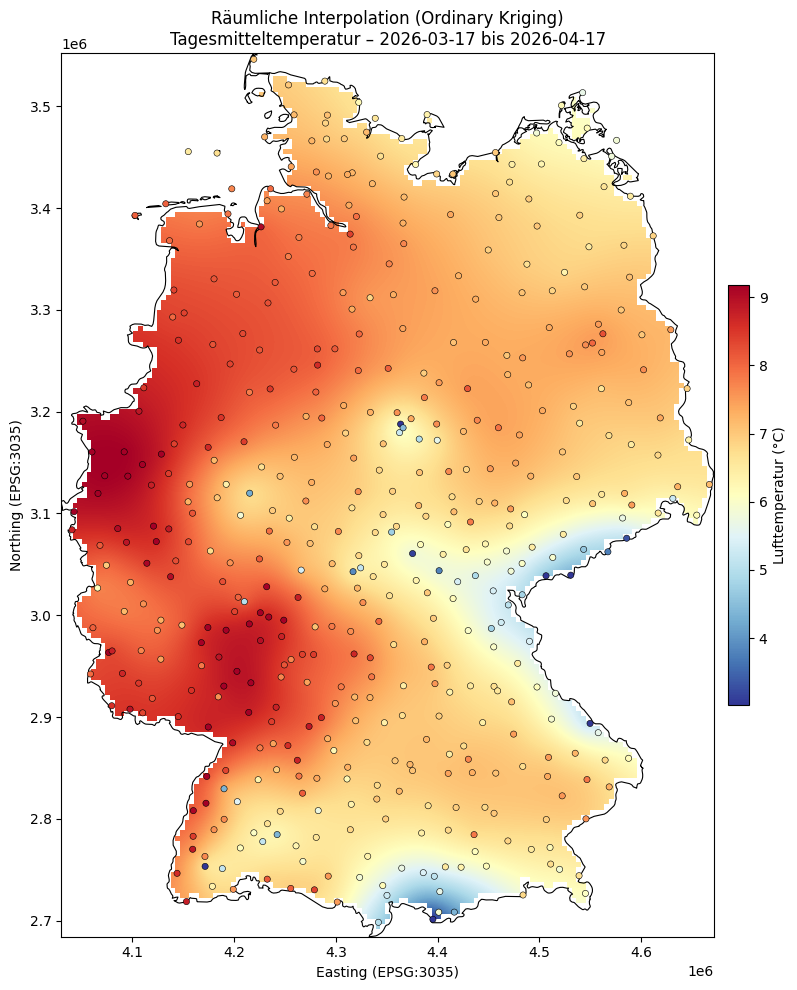

In [8]:
# Interpolationskarte visualisieren

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

img = ax.imshow(
    z_pred,
    extent=[min_x, max_x, min_y, max_y],
    origin="lower",
    cmap="RdYlBu_r",
    interpolation="bilinear",
)

# Alle Polygone zeichnen (Festland + Inseln)
for poly in germany_geom.geoms:
    coords = np.array(poly.exterior.coords)
    ax.plot(coords[:, 0], coords[:, 1], color="black", linewidth=0.8)

ax.scatter(
    stations_with_data["x"],
    stations_with_data["y"],
    c=stations_with_data["value"],
    cmap="RdYlBu_r",
    edgecolors="black",
    linewidths=0.4,
    s=20,
    zorder=5,
    norm=img.norm,
)

cbar = fig.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Lufttemperatur (°C)")

ax.set_title(f"Räumliche Interpolation (Ordinary Kriging)\nTagesmitteltemperatur – {date_label}", fontsize=12)
ax.set_xlabel("Easting (EPSG:3035)")
ax.set_ylabel("Northing (EPSG:3035)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

Inseln müssen angezeigt werden geopanda verwenden